# Business Summary

This notebook closes the project by translating the technical workflow into a concise business-facing story.

The earlier notebooks handled the technical work in stages: data audit, full-scale data-quality validation, exploratory monitoring, feature engineering, anomaly detection, and supervised modeling. That structure was necessary for analytical rigor, but decision-makers usually need a different kind of deliverable. They need a clear explanation of what was learned, where the most important risks sit, what the current controls miss, and what practical next steps should follow.

The purpose of this notebook is to bring those findings together in a transparent and professional way using the saved outputs from the earlier phases.


## 1. Preparing the notebook environment

This setup cell imports the libraries used for the summary notebook and configures the project root so that the notebook can locate the saved output tables.

The summary phase is intentionally lightweight. It does not rerun the heavy analytical steps. Instead, it reads the outputs created earlier and turns them into a final project narrative.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 2. Defining the saved output locations

This notebook draws from the output folders created in the earlier phases.

Using saved tables instead of rerunning everything again keeps the final summary stable and reproducible. It also reflects a realistic handoff pattern, where stakeholder-facing reports are often built from frozen project artifacts rather than from live exploratory state.


In [2]:
AUDIT_DIR = PROJECT_ROOT / "data" / "outputs" / "phase_2_audit"
MONITORING_DIR = PROJECT_ROOT / "data" / "outputs" / "phase_3_eda_monitoring"
ANOMALY_DIR = PROJECT_ROOT / "data" / "outputs" / "phase_5_anomaly_detection"
MODEL_DIR = PROJECT_ROOT / "data" / "outputs" / "phase_6_modeling"

for path in [AUDIT_DIR, MONITORING_DIR, ANOMALY_DIR, MODEL_DIR]:
    print(path.name, path.exists())


phase_2_audit True
phase_3_eda_monitoring True
phase_5_anomaly_detection True
phase_6_modeling True


## 3. Loading the key business tables

The summary notebook only needs a focused set of outputs rather than every intermediate artifact. These tables cover the business questions that matter most:

- how large the dataset is and how rare fraud is
- which transaction types carry the most risk
- how well the built-in rule-based flag performs
- whether anomaly detection concentrates fraud near the top of an alert queue
- which supervised model performed best on the held-out test period


In [3]:
audit_summary = pd.read_csv(AUDIT_DIR / "audit_summary.csv")
type_summary = pd.read_csv(MONITORING_DIR / "type_summary.csv")
flagged_eval = pd.read_csv(MONITORING_DIR / "flagged_fraud_evaluation.csv")
anomaly_topk = pd.read_csv(ANOMALY_DIR / "anomaly_topk_summary.csv") if (ANOMALY_DIR / "anomaly_topk_summary.csv").exists() else None
model_metrics = pd.read_csv(MODEL_DIR / "model_metrics.csv") if (MODEL_DIR / "model_metrics.csv").exists() else None

audit_summary


,metric,value
0,row_count,"6,362,620.0000"
1,chunk_count,26.0000
2,duplicate_rows,0.0000
3,fraud_count,"8,213.0000"
4,fraud_rate,0.0013


## 4. Framing the scale of the problem

One of the most important facts in this project is that fraud is extremely rare relative to the total transaction volume. That creates a difficult operating environment because naive metrics can be misleading.

This table provides the scale context needed for every later conclusion. It shows that the project is not dealing with a balanced classification problem. It is dealing with a rare-event detection problem inside a very large transaction stream.


In [4]:
audit_summary


,metric,value
0,row_count,"6,362,620.0000"
1,chunk_count,26.0000
2,duplicate_rows,0.0000
3,fraud_count,"8,213.0000"
4,fraud_rate,0.0013


## 5. Identifying where fraud is concentrated

The type-level summary is one of the clearest business findings in the project.

Fraud is not spread evenly across the transaction ecosystem. Instead, it is concentrated in a narrow set of transaction types, especially `TRANSFER` and `CASH_OUT`. That matters because it means monitoring effort and control design should not be distributed uniformly across all activity.


In [5]:
type_summary[[
    "type",
    "txn_count",
    "fraud_count",
    "fraud_rate",
    "share_of_all_txns",
    "share_of_all_fraud",
]]


,type,txn_count,fraud_count,fraud_rate,share_of_all_txns,share_of_all_fraud
0,TRANSFER,532909,4097,0.0077,0.0838,0.4988
1,CASH_OUT,2237500,4116,0.0018,0.3517,0.5012
2,CASH_IN,1399284,0,0.0000,0.2199,0.0000
3,DEBIT,41432,0,0.0000,0.0065,0.0000
4,PAYMENT,2151495,0,0.0000,0.3381,0.0000


## 6. Evaluating the built-in flagged-fraud rule

The PaySim data includes a built-in flagged-fraud indicator. On paper, that rule is very precise, but the precision alone is not enough to judge whether it is operationally useful.

What matters more is recall. If a rule flags almost no false positives but misses nearly every true fraud event, it may still be too weak to serve as the primary monitoring control.


In [6]:
flagged_eval


,metric,value
0,true_positives,16.0000
1,false_positives,0.0000
2,false_negatives,"8,197.0000"
3,true_negatives,"6,354,407.0000"
4,precision,1.0000
5,recall,0.0019
6,false_positive_rate,0.0000
7,alert_rate,0.0000


## 7. Reviewing anomaly-detection concentration

If the anomaly notebook outputs are available, this table shows whether the unsupervised alert ranking concentrates observed fraud near the top of the queue.

That result matters because anomaly detection can serve as a complementary monitoring layer. Even if it is not the final production model, it may still help analysts prioritize unusual transactions earlier.


In [7]:
if anomaly_topk is not None:
    anomaly_topk
else:
    print("Anomaly outputs are not available yet. Run notebook 05 or the project pipeline first.")


## 8. Reviewing supervised model performance

If the modeling outputs are available, this table compares the supervised models on the held-out test period.

The business value here is not just which model wins. It is whether the project has advanced from descriptive insight to a measurable detection workflow that can rank or classify transactions more effectively than the built-in baseline rule.


In [8]:
if model_metrics is not None:
    model_metrics
else:
    print("Model outputs are not available yet. Run notebook 06 or the project pipeline first.")


## 9. Visualizing the highest-risk transaction types

A visual summary makes it easier to communicate where fraud risk is concentrated. This is useful for stakeholders because it turns a technical summary table into a direct prioritization view.


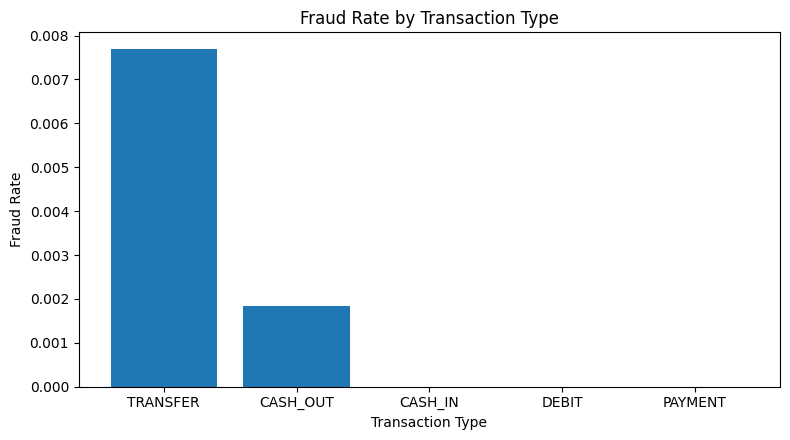

In [9]:
plot_df = type_summary.sort_values("fraud_rate", ascending=False)

plt.figure(figsize=(8, 4.5))
plt.bar(plot_df["type"], plot_df["fraud_rate"])
plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 10. Business interpretation

The project supports four high-level conclusions.

First, the data quality is strong enough to support downstream analytics at full scale. The full-dataset audit found no missing values and no duplicate rows, which removes several common data-readiness barriers.

Second, fraud is both rare and concentrated. It is rare at the full-dataset level, but it is heavily concentrated in specific transaction types and in certain behavioral patterns. That means broad undifferentiated controls are unlikely to be the most efficient response.

Third, the built-in flag appears extremely narrow. Its precision is high, but its recall is very low, which suggests that it acts more like an extreme-rule trigger than a comprehensive fraud-monitoring control.

Fourth, the project now has two stronger analytical extensions beyond that baseline: an anomaly-ranking layer and a supervised modeling layer. Together, they create a more realistic path toward risk prioritization and future production scoring.


## 11. Recommended next steps

The most practical next actions after this project are:

- prioritize `TRANSFER` and `CASH_OUT` for deeper control design and alert routing
- validate the top anomaly segments manually to confirm whether the ranked alerts reflect actionable fraud patterns
- promote the strongest supervised model into a more formal threshold-tuning and monitoring workflow
- extend the project with cost-sensitive evaluation so that alert volume, missed fraud, and investigator capacity can be balanced explicitly
- build a lightweight dashboard from the saved CSV outputs so the monitoring layer can be reviewed without rerunning notebooks

These steps would move the work from portfolio-quality technical analysis toward a more operational fraud analytics prototype.


## 12. Final project closeout

This notebook completes the end-to-end fraud risk monitoring project.

Across the full workflow, the project now includes:

- scalable data loading and validation
- full-dataset quality audit outputs
- descriptive fraud monitoring and business summaries
- history-aware feature engineering
- unsupervised anomaly scoring
- time-aware supervised fraud modeling
- a final stakeholder-ready summary layer

That structure is strong for both portfolio presentation and technical handoff because it shows analytical rigor, modular implementation, and a clear narrative from raw data to actionable business insight.
